In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline



pipeline=Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',LogisticRegression())
])
pipeline.fit(x_train,y_train)
pipeline.predict(x_test)

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

iris = load_iris()

X = iris.data
y = iris.target

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipe.fit(X_train,y_train)

print(pipe.score(X_test,y_test))

1.0


In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

pipe = Pipeline([

('scale',StandardScaler()),

('feature',SelectKBest(score_func=f_classif,k=2)),

('model',LogisticRegression())

])

pipe.fit(X_train,y_train)

Pipeline(steps=[('scale', StandardScaler()), ('feature', SelectKBest(k=2)),
                ('model', LogisticRegression())])

In [ ]:
from sklearn.decomposition import PCA

pipe = Pipeline([

('scale',StandardScaler()),

('pca',PCA(n_components=2)),

('model',LogisticRegression())

])

pipe.fit(X_train,y_train)

Pipeline(steps=[('scale', StandardScaler()), ('pca', PCA(n_components=2)),
                ('model', LogisticRegression())])

In [ ]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([

('scale',StandardScaler()),

('model',LogisticRegression())

])

params = {

'model__C':[0.1,1,10],

'model__solver':['lbfgs','liblinear']

}

grid = GridSearchCV(pipe,
                    params,
                    cv=5)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'model__C': 1, 'model__solver': 'lbfgs'}


CLASSIFICATION METRICS
Accuracy : 0.9736842105263158
Precision: 0.9722222222222222
Recall   : 0.9859154929577465
F1 Score : 0.9790209790209791

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix
[[41  2]
 [ 1 70]]


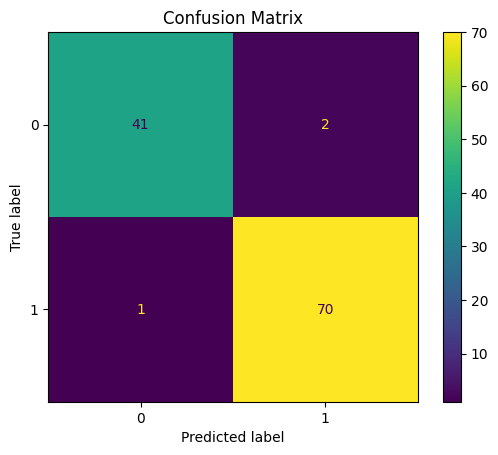

ROC-AUC Score: 0.99737962659679


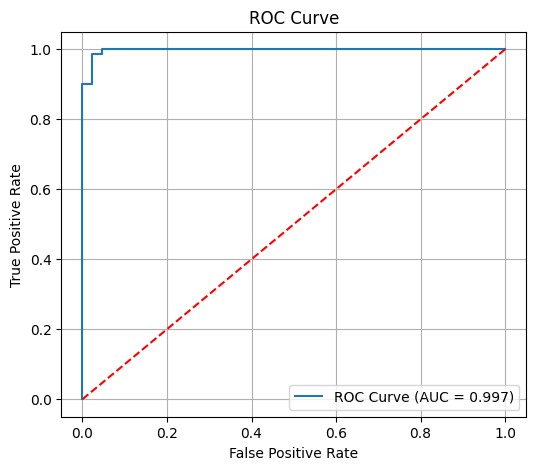

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# Load Dataset
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

# Train Model
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print("="*60)
print("CLASSIFICATION METRICS")
print("="*60)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix")
plt.show()

# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve (AUC = %.3f)" % auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Pipeline
regression_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Train
regression_pipeline.fit(X_train, y_train)

# Predict
pred = regression_pipeline.predict(X_test)

print("\n")
print("="*60)
print("REGRESSION METRICS")
print("="*60)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)



REGRESSION METRICS
MAE : 42.79409467959994
MSE : 2900.1936284934823
RMSE: 53.853445836765935
R² Score: 0.45260276297191926
